In [1]:
%load_ext autoreload
%autoreload 2


In [ ]:
from sklearn.preprocessing import MinMaxScaler

import sys
import os



In [3]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

CUDA available: True
GPU count: 2
GPU 0: NVIDIA GeForce RTX 3070
GPU 1: NVIDIA GeForce RTX 3070


device(type='cpu')

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [5]:
import matplotlib.pyplot as plt

def preview_training_data(dataset, variables_used , num_samples=3):
    fig, axs = plt.subplots(num_samples, 1, figsize=(12, 4 * num_samples), sharex=True)

    for i in range(num_samples):
        x, y = dataset[i]
        x_np = x.numpy()
        y_np = y.numpy()

        for feature_idx in range(x_np.shape[1]):
            axs[i].plot(x_np[:, feature_idx], label=f'X: {variables_used[feature_idx]}', linestyle='-')

        for feature_idx in range(y_np.shape[1]):
            axs[i].plot(
                range(x_np.shape[0], x_np.shape[0] + y_np.shape[0]),
                y_np[:, feature_idx],
                label=f'Y: {variables_used[feature_idx]}',
                linestyle='--'
            )

        axs[i].legend()
        axs[i].set_title(f"Sample {i + 1}")
        axs[i].set_xlabel("Time step")
        axs[i].set_ylabel("Normalized Value")

    plt.tight_layout()
    plt.show()


In [17]:
import torch
import mlflow.pytorch
import os
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# 1) Auth FIRST (choose basic or token; shown here: basic)
os.environ["MLFLOW_TRACKING_USERNAME"] = "user"
os.environ["MLFLOW_TRACKING_PASSWORD"] = "SHIUZ1YJvMbu"

import mlflow
from mlflow import MlflowClient

mlflow.set_tracking_uri("http://172.16.0.200")  # or http://172.16.0.200/mlflow if served behind /mlflow
client = MlflowClient()

model_uri = "models:/GRUStacked_in100-out_12bs64_lr0.001_win30_feat1/1"  # or the renamed clean name if you changed it
model = mlflow.pytorch.load_model(model_uri).to(device)
model.eval()


GRUStacked(
  (gru): GRU(1, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=12, bias=True)
)

Whoami: alice
URI: http://172.16.0.200


MlflowException: API request to endpoint /api/2.0/mlflow/experiments/search failed with error code 401 != 200. Response body: 'You are not authenticated. Please see https://www.mlflow.org/docs/latest/auth/index.html#authenticating-to-mlflow on how to authenticate.'

In [2]:
from itertools import combinations, product
# --- MLflow setup ---
import os, mlflow, mlflow.pytorch
from mlflow.models import infer_signature
import copy
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler
from btc_forecast.data_loader import load_or_download


import numpy as np
from btc_forecast.data_loader import load_or_download
from btc_forecast.data_processing import train_test, normalize
from btc_forecast.windowed_dataset import WindowedDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.environ["TORCH_COMPILE_DISABLE"] = "1"   # PyTorch 2.x compiler switch
os.environ["TORCHDYNAMO_DISABLE"] = "1"

# 1) Auth FIRST (choose basic or token; shown here: basic)
os.environ["MLFLOW_TRACKING_USERNAME"] = "user"
os.environ["MLFLOW_TRACKING_PASSWORD"] = "SHIUZ1YJvMbu"

# 2) Set the REAL tracking URI (do NOT put creds here)
# If your server is behind a path, include it, e.g. "http://172.16.0.200/mlflow"
TRACKING_URI = "http://172.16.0.200"
mlflow.set_tracking_uri(TRACKING_URI)

# 3) Select experiment
mlflow.set_experiment("crypto_forecasting_v1")


models =[]

base_features = ['close', 'open', 'high', 'low', 'volume']
variable_sets = [list(c) for i in range(1, len(base_features)+1) for c in combinations(base_features, i)]


# Hyperparameter grid
param_grid = {
    "input_width": [100, 200],
    "label_width": [6, 12, 24],
    "batch_size": [32, 64],
    "learning_rate": [0.001, 0.0005],
    "num_epochs": [50],  # can expand later
    "windows_normalization_length": [30 ,15],
}

all_combinations = list(product(
    variable_sets,
    param_grid["input_width"],
    param_grid["label_width"],
    param_grid["batch_size"],
    param_grid["learning_rate"],
    param_grid["num_epochs"],
    param_grid["windows_normalization_length"]
))

for (variables_used, input_width, label_width, batch_size,
     learning_rate, num_epochs, windows_normalization_length) in all_combinations:
    
    if "close" not in variables_used:
        continue

    # ✅ Reset models per-combo (avoid growing/duplicating across runs)
    models = []

    print(f"Variables: {variables_used}, Input Width: {input_width}, Label Width: {label_width}, "
          f"Batch Size: {batch_size}, Learning Rate: {learning_rate}, Num Epochs: {num_epochs}, "
          f"Windows Normalization Length: {windows_normalization_length}")
    # Load the model

    close_idx = variables_used.index("close")
    coin="BTCUSDT"
    ## SImple Linear 
    model_config = {
    "input_width": input_width,
    "label_width": label_width,
    "num_features": len(variables_used),
    "conv_channels": 16,        # NEW
    "kernel_size": 3            # NEW
        }
    class ConvFC(nn.Module):

        def __init__(self, input_width, label_width, num_features, conv_channels=16, kernel_size=3):
            super(ConvFC, self).__init__()

            self.input_width = input_width
            self.label_width = label_width
            self.num_features = num_features
            self.conv_channels = conv_channels
            self.kernel_size = kernel_size

            conv_output_width = input_width - kernel_size + 1
            input_dim = conv_output_width * conv_channels
            output_dim = label_width * num_features

            self.conv = nn.Conv1d(
                in_channels=num_features,
                out_channels=conv_channels,
                kernel_size=kernel_size
            )

            self.fc = nn.Sequential(
                nn.Linear(input_dim, 128),
                nn.ReLU(),
                nn.Linear(128, output_dim)
            )

        def forward(self, x):
            # x: (batch_size, input_width, num_features)
            x = x.permute(0, 2, 1)        # → (batch_size, num_features, input_width)
            x = self.conv(x)              # → (batch_size, conv_channels, output_width)
            x = x.flatten(start_dim=1)    # → (batch_size, conv_channels * output_width)
            x = self.fc(x)                # → (batch_size, label_width * num_features)
            return x.view(-1, self.label_width, self.num_features)

    models.append(ConvFC(**model_config))

    model_config = {
        "input_width": input_width,
        "label_width": label_width,
        #"hidden_size": 64,
        #"num_layers": 2,
        "num_features": len(variables_used),
        }
    class SimpleFC(nn.Module):
        def __init__(self, input_width, label_width, num_features):
            super(SimpleFC, self).__init__()
            self.input_width = input_width
            self.label_width = label_width
            self.num_features = num_features
            input_dim = input_width * num_features
            output_dim = label_width * num_features

            self.fc = nn.Sequential(
                nn.Flatten(start_dim=1),
                nn.Linear(input_dim, 128),
                nn.ReLU(),
                nn.Linear(128, output_dim)
            )
        def forward(self, x):
            x = self.fc(x)                             # → (batch_size, label_width * num_features)
            return x.view(-1, self.label_width, self.num_features) 
    models.append(SimpleFC(**model_config))
    #GRU
    model_config = {
        "input_width": input_width,
        "label_width": label_width,
        "hidden_size": 64,
        "num_layers": 2,
        "num_features": len(variables_used),
        }
    class GRUStacked(nn.Module):
        def __init__(self, input_width, label_width, num_features, hidden_size=64, num_layers=2):
            super(GRUStacked, self).__init__()
            self.gru = nn.GRU(
                input_size=num_features,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True
            )
            self.fc = nn.Linear(hidden_size, label_width * num_features)
            self.label_width = label_width
            self.num_features = num_features

        def forward(self, x):
            out, _ = self.gru(x)
            out = out[:, -1, :]  # take the output from the last timestep
            out = self.fc(out)
            return out.view(-1, self.label_width, self.num_features)
    models.append(GRUStacked(**model_config))

    ## Transormer
    model_config = {
        "input_width": input_width,
        "label_width": label_width,
        "hidden_size": 64,
        "num_layers": 2,
        "num_features": len(variables_used),
        }

    class TransformerTimeSeries(nn.Module):
        def __init__(self, input_width, label_width, num_features, hidden_size=64, num_layers=3, nhead=4):
            super(TransformerTimeSeries, self).__init__()
            self.input_width = input_width
            self.label_width = label_width
            self.num_features = num_features
            self.hidden_size = hidden_size

            self.input_projection = nn.Linear(num_features, hidden_size)

            self.positional_encoding = nn.Parameter(torch.randn(1, input_width, hidden_size))

            encoder_layer = nn.TransformerEncoderLayer(
                d_model=hidden_size,
                nhead=nhead,
                dim_feedforward=hidden_size * 4,
                dropout=0.1,
                batch_first=True
            )
            self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

            self.output_layer = nn.Linear(hidden_size, label_width * num_features)

        def forward(self, x):
            # x shape: (batch_size, input_width, num_features)
            x = self.input_projection(x)  # (batch_size, input_width, hidden_size)
            x = x + self.positional_encoding[:, :x.size(1), :]  # Add positional encoding

            encoded = self.transformer_encoder(x)  # (batch_size, input_width, hidden_size)
            last_token = encoded[:, -1, :]  # Take the last time step
            out = self.output_layer(last_token)  # (batch_size, label_width * num_features)

            return out.view(-1, self.label_width, self.num_features)
    models.append(TransformerTimeSeries(**model_config))

    #TRAN THE MODEL 

    def train_model(
        coin,
        model,
        input_width=200,
        label_width=12,
        lr=1e-3,
        max_epochs=num_epochs,
        patience=5,
        
    ):

    

        df = load_or_download(coin)
        #if 'volume' in df.columns:
        #    df["volume"] = np.log1p(df["volume"])
        #df_norm = normalize(df, label_width=label_width, window=30)

        # 1) Normalize causally (ok to do before split)
        df_z = normalize(df[variables_used], label_width=label_width, window=windows_normalization_length)

        # 2) Split
        train_df, val_df, test_df = train_test(df_z)

        # 3) Fit MinMax *only* on train, transform val/test
        scaler = MinMaxScaler(feature_range=(-1, 1))
        train_df[train_df.columns] = scaler.fit_transform(train_df)
        val_df[val_df.columns]     = scaler.transform(val_df)
        test_df[test_df.columns]    = scaler.transform(test_df)

        train_ds = WindowedDataset(train_df, input_width, label_width, 0, variables_used)
        preview_training_data(train_ds, variables_used, num_samples=5)


        val_ds = WindowedDataset(val_df, input_width, label_width, 0, variables_used)

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=batch_size)
        print( model.parameters)
        optimizer = optim.Adam(model.parameters(), lr=lr)
        loss_fn = nn.MSELoss()

        train_losses, val_losses = [], []
        best_val_loss = float("inf")
        best_weights = None
        early_stop_counter = 0

        



        for epoch in range(max_epochs):
            model.train()
            running_loss = 0.0
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                loss = loss_fn(preds, yb)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                running_loss += loss.item()

            train_loss = running_loss / len(train_loader)
            train_losses.append(train_loss)

            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    preds = model(xb)
                    val_loss += loss_fn(preds, yb).item()
            val_loss /= len(val_loader)
            val_losses.append(val_loss)
            if mlflow.active_run():
                mlflow.log_metric("train_loss", float(train_loss), step=epoch+1)
                mlflow.log_metric("val_loss", float(val_loss), step=epoch+1)

            print(f"📉 Epoch {epoch+1}: Train={train_loss:.4f} | Val={val_loss:.4f}")

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_weights = model.state_dict()
                early_stop_counter = 0
            else:
                early_stop_counter += 1
                if early_stop_counter >= patience:
                    print("🛑 Early stopping")
                    break

        return model, best_weights, train_losses, val_losses , scaler
    print(f"Variables: {variables_used}, Input Width: {input_width}, Label Width: {label_width}, "
          f"Batch Size: {batch_size}, Learning Rate: {learning_rate}, Num Epochs: {num_epochs}, "
          f"Windows Normalization Length: {windows_normalization_length}")

  

    for model in models:
        run_name = (
            f"{model.__class__.__name__}"
            f"|in{input_width}-out{label_width}"
            f"|bs{batch_size}|lr{learning_rate}"
            f"|win{windows_normalization_length}"
            f"|feat{len(variables_used)}"
        )

        with mlflow.start_run(run_name=run_name):
            # (params/tags/train) unchanged...

            model.to(device)
            model, weights, train_l, val_l, scaler = train_model(
                coin=coin,
                model=model,
                input_width=input_width,
                label_width=label_width,
                lr=learning_rate,
                max_epochs=num_epochs,
                patience=5
            )

            # --- NEW: ensure we evaluate the BEST checkpoint, not the last ---
            if weights is None:
                weights = copy.deepcopy(model.state_dict())
            model.load_state_dict(weights)
            model.eval()

            # ---- Eval (unchanged logic, now runs with best weights) ----
            df = load_or_download(coin)
            _, _, validate_raw = train_test(df[variables_used])

            test_df_zscore = normalize(validate_raw, label_width, window=windows_normalization_length)
            test_df_scaled = scaler.transform(test_df_zscore)
            test_df_scaled = pd.DataFrame(test_df_scaled, columns=test_df_zscore.columns, index=test_df_zscore.index)

            test_ds = WindowedDataset(test_df_scaled, input_width, label_width, 0, variables_used)
            test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

            all_preds, all_targets = [], []
            with torch.no_grad():
                for xb, yb in test_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    pred = model(xb)
                    all_preds.append(pred.cpu().numpy())
                    all_targets.append(yb.cpu().numpy())

            all_preds = np.concatenate(all_preds, axis=0)
            all_targets = np.concatenate(all_targets, axis=0)

            preds_minmax = all_preds[:, :, close_idx]
            targets_minmax = all_targets[:, :, close_idx]

            close_min = scaler.data_min_[close_idx]
            close_max = scaler.data_max_[close_idx]
            preds_zscore = 0.5 * (preds_minmax + 1) * (close_max - close_min) + close_min
            targets_zscore = 0.5 * (targets_minmax + 1) * (close_max - close_min) + close_min

            denorm_preds = np.zeros_like(preds_zscore)
            denorm_targets = np.zeros_like(targets_zscore)
            for i in range(preds_zscore.shape[0]):
                for j in range(label_width):
                    idx = i + j + input_width
                    mean = validate_raw["close"].shift(label_width).rolling(window=windows_normalization_length).mean().iloc[idx]
                    std  = validate_raw["close"].shift(label_width).rolling(window=windows_normalization_length).std().iloc[idx]
                    denorm_preds[i, j]   = preds_zscore[i, j] * std + mean
                    denorm_targets[i, j] = targets_zscore[i, j] * std + mean

            from sklearn.metrics import mean_absolute_error, mean_squared_error
            mae  = mean_absolute_error(denorm_targets.flatten(), denorm_preds.flatten())
            rmse = np.sqrt(mean_squared_error(denorm_targets.flatten(), denorm_preds.flatten()))

            mlflow.log_metric("final_mae", float(mae))
            mlflow.log_metric("final_rmse", float(rmse))
            mlflow.log_metric("final_mae_per_step", float(mae / label_width))
            mlflow.log_metric("final_rmse_per_step", float(rmse / label_width))
            mlflow.log_metric("train_loss_last", float(train_l[-1]))
            mlflow.log_metric("val_loss_last", float(val_l[-1]))

            mlflow.log_dict({
                "MAE/step": float(mae / label_width),
                "RMSE/step": float(rmse / label_width),
                "Model": model.__class__.__name__,
                "Coin": coin,
                "Input Width": input_width,
                "Label Width": label_width,
                "Batch Size": batch_size,
                "Learning Rate": learning_rate,
                "Num Epochs": num_epochs,
                "Windows Normalization Length": windows_normalization_length,
                "Train Loss Last": float(train_l[-1]),
                "Val Loss Last": float(val_l[-1]),
                "Features": ",".join(variables_used),
            }, artifact_file="summary.json")

            # --- Log model (already using best weights from above) ---
            model_to_log = copy.deepcopy(model).to("cpu").eval()
            input_example = np.zeros((1, input_width, len(variables_used)), dtype=np.float32)
            with torch.no_grad():
                sample_out = model_to_log(torch.from_numpy(input_example))
            signature = infer_signature(input_example, sample_out.cpu().numpy())
            pip_reqs = ["mlflow", "torch==2.5.1", "numpy>=1.24,<3", "pandas>=2.0,<3", "scikit-learn>=1.3,<2"]
            mlflow.pytorch.log_model(
                model_to_log,
                artifact_path="model",
                input_example=input_example,
                signature=signature,
                pip_requirements=pip_reqs,
            )

ModuleNotFoundError: No module named 'btc_forecast'

ERROR: unknown command "isntall" - maybe you meant "install"


2025/09/16 14:01:03 INFO mlflow.tracking.fluent: Experiment with name 'test-linear-regression' does not exist. Creating a new experiment.
2025/09/16 14:01:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/16 14:01:12 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Logged run with MSE: 97.2562
🏃 View run burly-croc-814 at: http://172.16.0.200/#/experiments/1/runs/4ef8e2da9aa94be8899d988b2a80fa95
🧪 View experiment at: http://172.16.0.200/#/experiments/1


2025/09/16 17:16:17 INFO mlflow.tracking.fluent: Experiment with name 'crypto_forecasting' does not exist. Creating a new experiment.


📁 Loading BTCUSDT from /media/alice/SeagateLinux/alice_backup/btc_forecast/Data/BTCUSDT.csv
          close
20    -1.251469
21    -1.921129
22    -1.632046
23    -1.275108
24    -1.320543
...         ...
66790 -0.266570
66791 -1.048533
66792 -2.135558
66793 -4.231040
66794 -3.869856

[66775 rows x 1 columns]


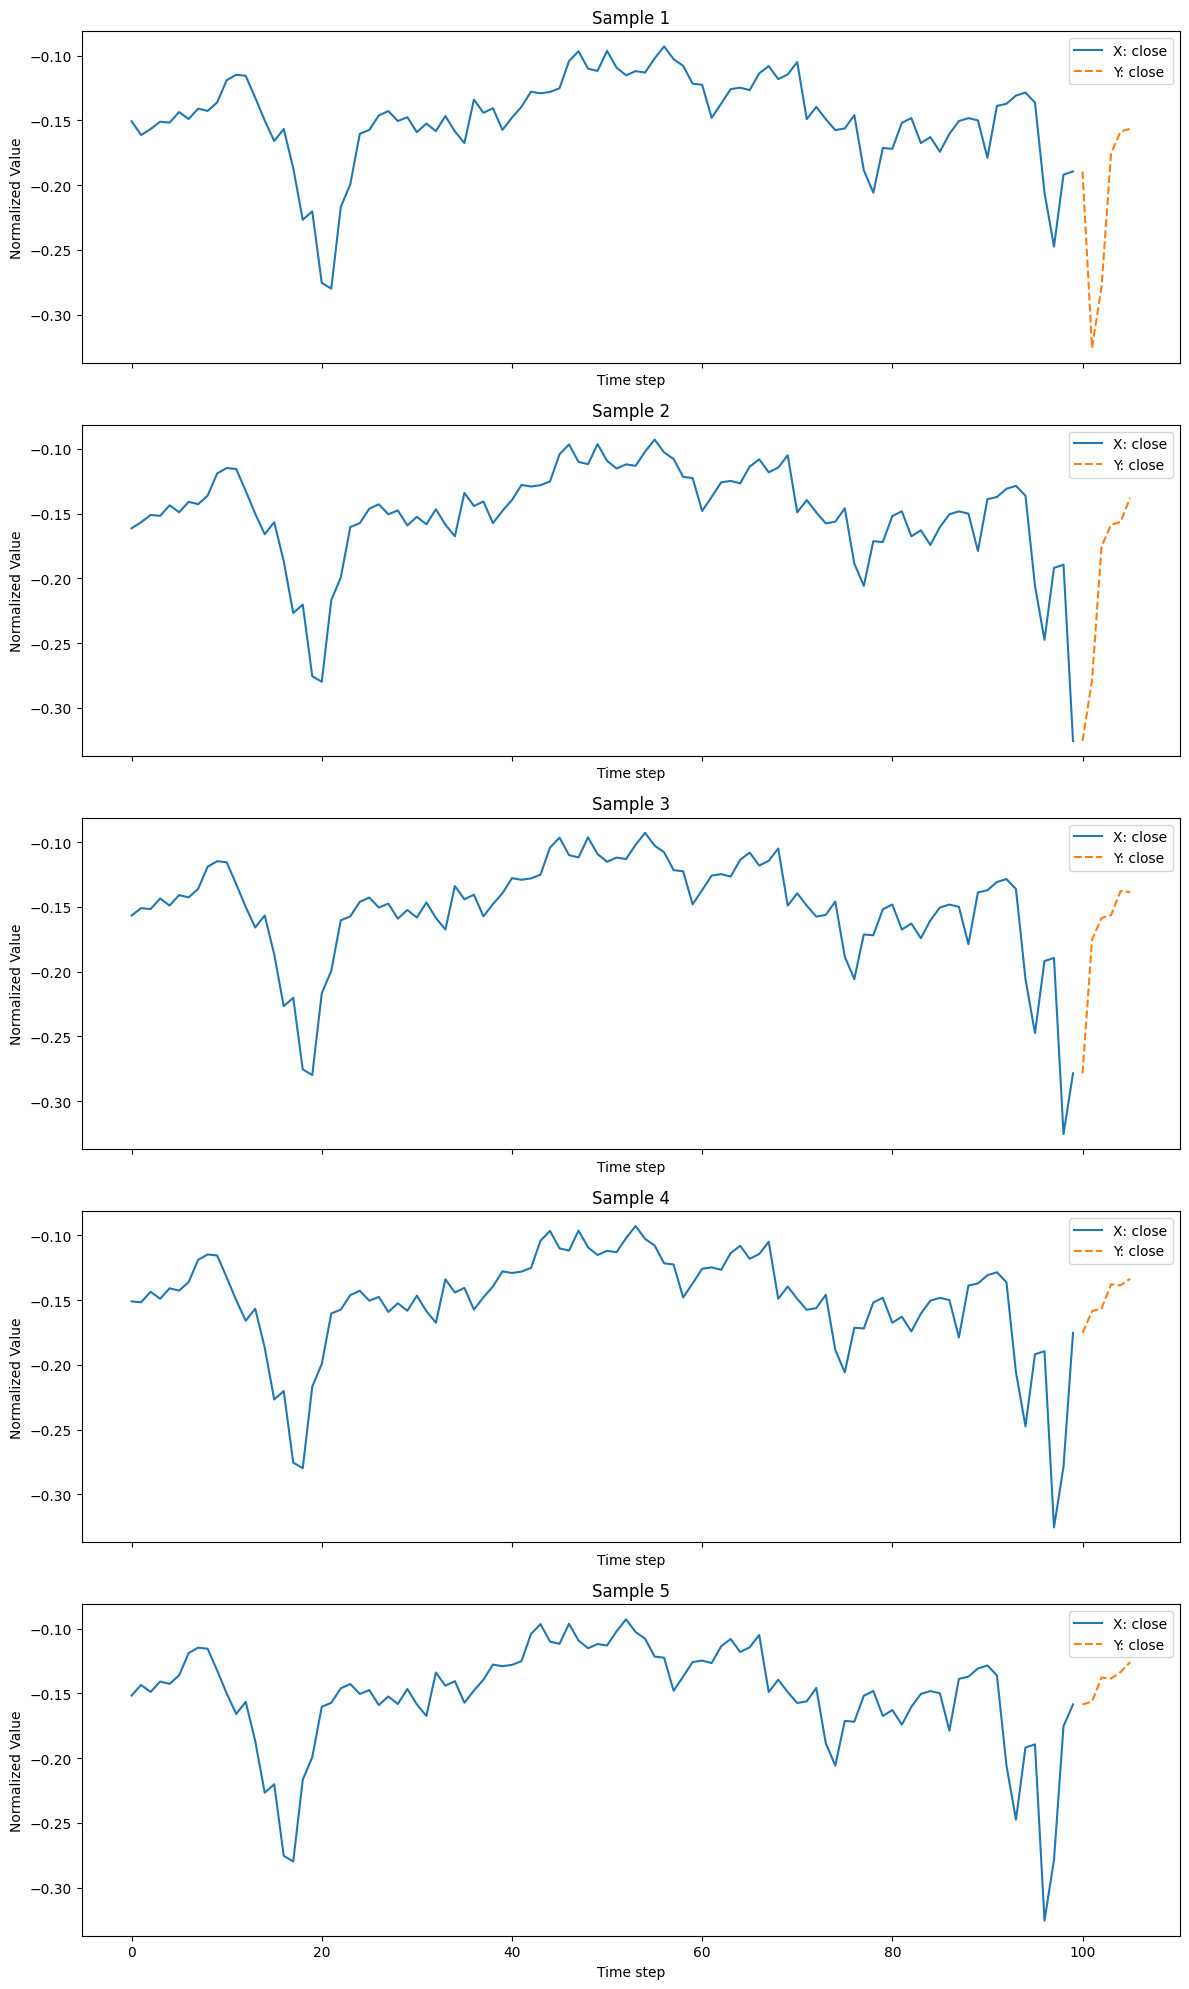

<bound method Module.parameters of ConvFC(
  (conv): Conv1d(1, 16, kernel_size=(3,), stride=(1,))
  (fc): Sequential(
    (0): Linear(in_features=1568, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=6, bias=True)
  )
)>
📉 Epoch 1: Train=0.0011 | Val=0.0013
📉 Epoch 2: Train=0.0011 | Val=0.0013
📉 Epoch 3: Train=0.0011 | Val=0.0013
📉 Epoch 4: Train=0.0011 | Val=0.0013
📉 Epoch 5: Train=0.0011 | Val=0.0013
📉 Epoch 6: Train=0.0011 | Val=0.0013
📉 Epoch 7: Train=0.0011 | Val=0.0013
📉 Epoch 8: Train=0.0011 | Val=0.0013
📉 Epoch 9: Train=0.0011 | Val=0.0013
📉 Epoch 10: Train=0.0011 | Val=0.0013
📉 Epoch 11: Train=0.0011 | Val=0.0013
📉 Epoch 12: Train=0.0011 | Val=0.0013
📉 Epoch 13: Train=0.0011 | Val=0.0013
📉 Epoch 14: Train=0.0011 | Val=0.0013
📉 Epoch 15: Train=0.0011 | Val=0.0013
🛑 Early stopping
📁 Loading BTCUSDT from /media/alice/SeagateLinux/alice_backup/btc_forecast/Data/BTCUSDT.csv


2025/09/16 17:18:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/16 17:18:12 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/09/16 17:18:15 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/09/16 17:18:15 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter whe

✅ ConvFC | MAE=629.6682 RMSE=1276.4697
🏃 View run ConvFC-BTCUSDT at: http://172.16.0.200/#/experiments/3/runs/991494ad61e14342892d3016c87f2a76
🧪 View experiment at: http://172.16.0.200/#/experiments/3
📁 Loading BTCUSDT from /media/alice/SeagateLinux/alice_backup/btc_forecast/Data/BTCUSDT.csv
          close
20    -1.251469
21    -1.921129
22    -1.632046
23    -1.275108
24    -1.320543
...         ...
66790 -0.266570
66791 -1.048533
66792 -2.135558
66793 -4.231040
66794 -3.869856

[66775 rows x 1 columns]


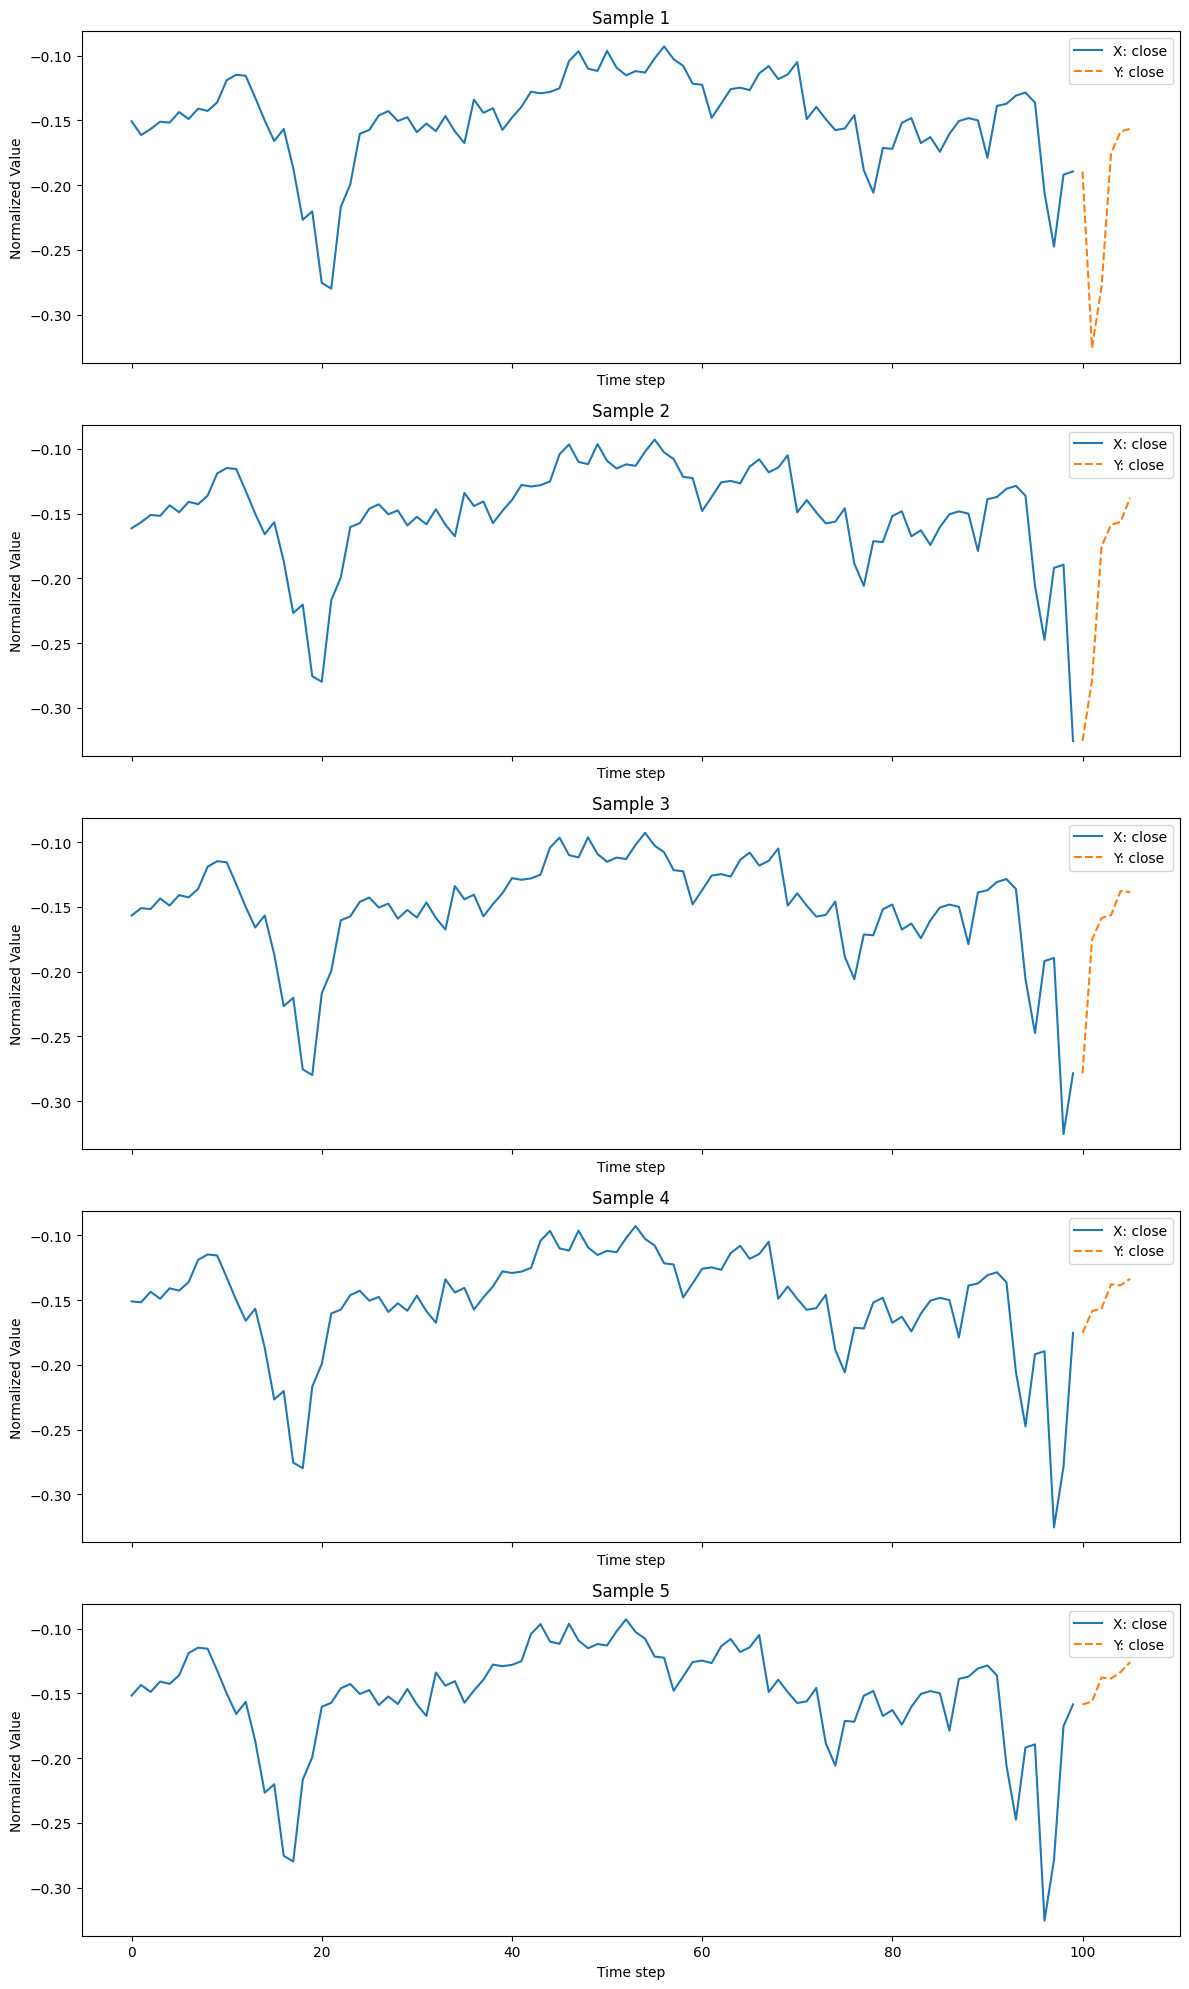

<bound method Module.parameters of SimpleFC(
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=6, bias=True)
  )
)>
📉 Epoch 1: Train=0.0015 | Val=0.0014
📉 Epoch 2: Train=0.0013 | Val=0.0013
📉 Epoch 3: Train=0.0012 | Val=0.0013
📉 Epoch 4: Train=0.0012 | Val=0.0013
📉 Epoch 5: Train=0.0012 | Val=0.0013
📉 Epoch 6: Train=0.0012 | Val=0.0013
📉 Epoch 7: Train=0.0012 | Val=0.0013
📉 Epoch 8: Train=0.0012 | Val=0.0013
📉 Epoch 9: Train=0.0012 | Val=0.0013
📉 Epoch 10: Train=0.0012 | Val=0.0013
📉 Epoch 11: Train=0.0012 | Val=0.0013
📉 Epoch 12: Train=0.0012 | Val=0.0014
📉 Epoch 13: Train=0.0012 | Val=0.0014
📉 Epoch 14: Train=0.0012 | Val=0.0015
🛑 Early stopping
📁 Loading BTCUSDT from /media/alice/SeagateLinux/alice_backup/btc_forecast/Data/BTCUSDT.csv


2025/09/16 17:20:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/16 17:20:08 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/09/16 17:20:11 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/09/16 17:20:11 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter whe

✅ SimpleFC | MAE=827.1914 RMSE=1435.6923
🏃 View run SimpleFC-BTCUSDT at: http://172.16.0.200/#/experiments/3/runs/b6e653068d5e457da9b020672d0bf0b0
🧪 View experiment at: http://172.16.0.200/#/experiments/3
📁 Loading BTCUSDT from /media/alice/SeagateLinux/alice_backup/btc_forecast/Data/BTCUSDT.csv
          close
20    -1.251469
21    -1.921129
22    -1.632046
23    -1.275108
24    -1.320543
...         ...
66790 -0.266570
66791 -1.048533
66792 -2.135558
66793 -4.231040
66794 -3.869856

[66775 rows x 1 columns]


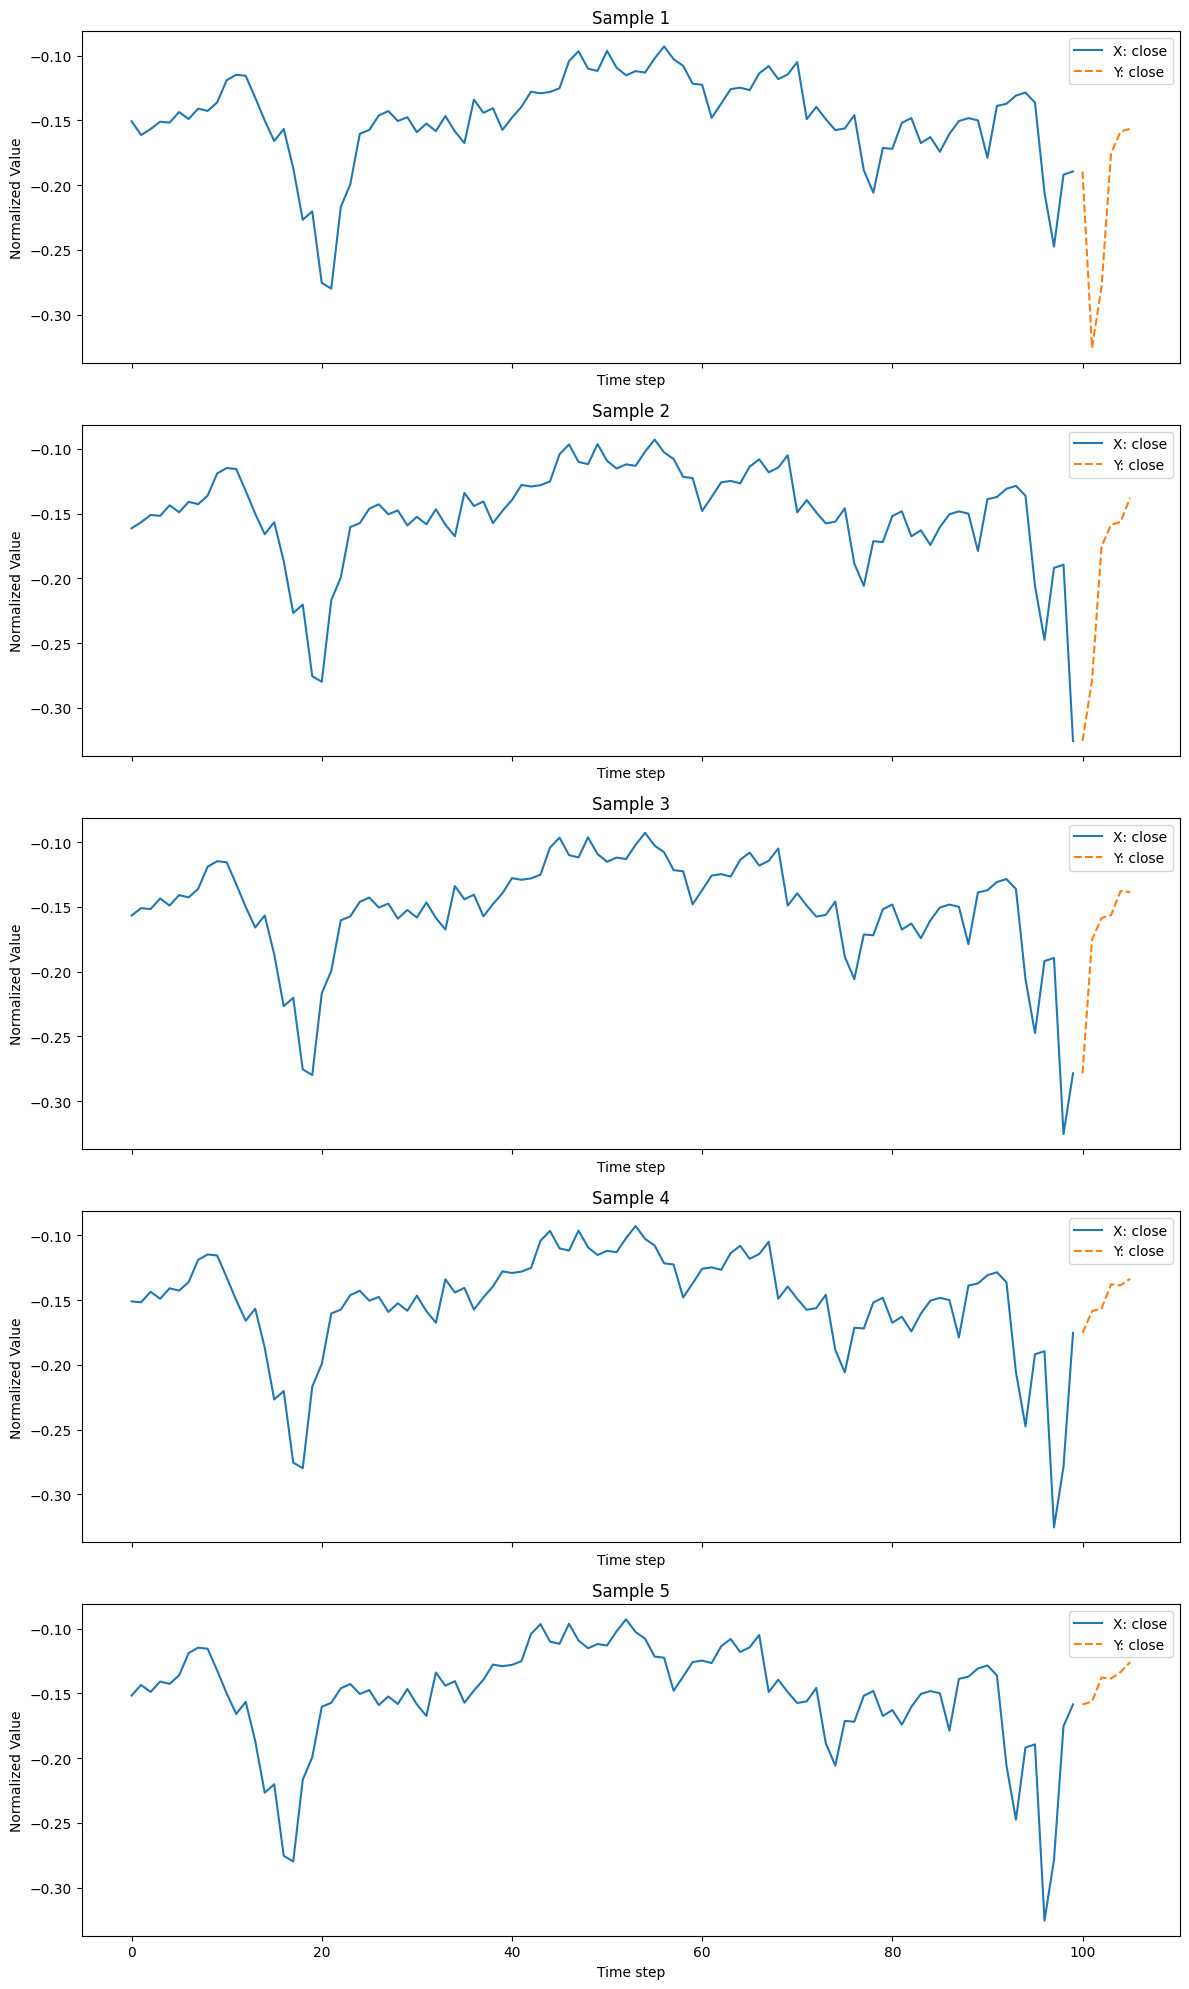

<bound method Module.parameters of GRUStacked(
  (gru): GRU(1, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=6, bias=True)
)>
📉 Epoch 1: Train=0.0015 | Val=0.0014
📉 Epoch 2: Train=0.0013 | Val=0.0013
📉 Epoch 3: Train=0.0013 | Val=0.0014
📉 Epoch 4: Train=0.0012 | Val=0.0013
📉 Epoch 5: Train=0.0012 | Val=0.0012
📉 Epoch 6: Train=0.0011 | Val=0.0012
📉 Epoch 7: Train=0.0011 | Val=0.0012
📉 Epoch 8: Train=0.0011 | Val=0.0012
📉 Epoch 9: Train=0.0011 | Val=0.0012
📉 Epoch 10: Train=0.0011 | Val=0.0012
📉 Epoch 11: Train=0.0011 | Val=0.0012
📉 Epoch 12: Train=0.0011 | Val=0.0012
🛑 Early stopping
📁 Loading BTCUSDT from /media/alice/SeagateLinux/alice_backup/btc_forecast/Data/BTCUSDT.csv


2025/09/16 17:22:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/16 17:22:17 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/09/16 17:22:20 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/09/16 17:22:20 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter whe

✅ GRUStacked | MAE=613.7509 RMSE=1216.0475
🏃 View run GRUStacked-BTCUSDT at: http://172.16.0.200/#/experiments/3/runs/968496c7822440c4867dac19514dfdd3
🧪 View experiment at: http://172.16.0.200/#/experiments/3
📁 Loading BTCUSDT from /media/alice/SeagateLinux/alice_backup/btc_forecast/Data/BTCUSDT.csv
          close
20    -1.251469
21    -1.921129
22    -1.632046
23    -1.275108
24    -1.320543
...         ...
66790 -0.266570
66791 -1.048533
66792 -2.135558
66793 -4.231040
66794 -3.869856

[66775 rows x 1 columns]


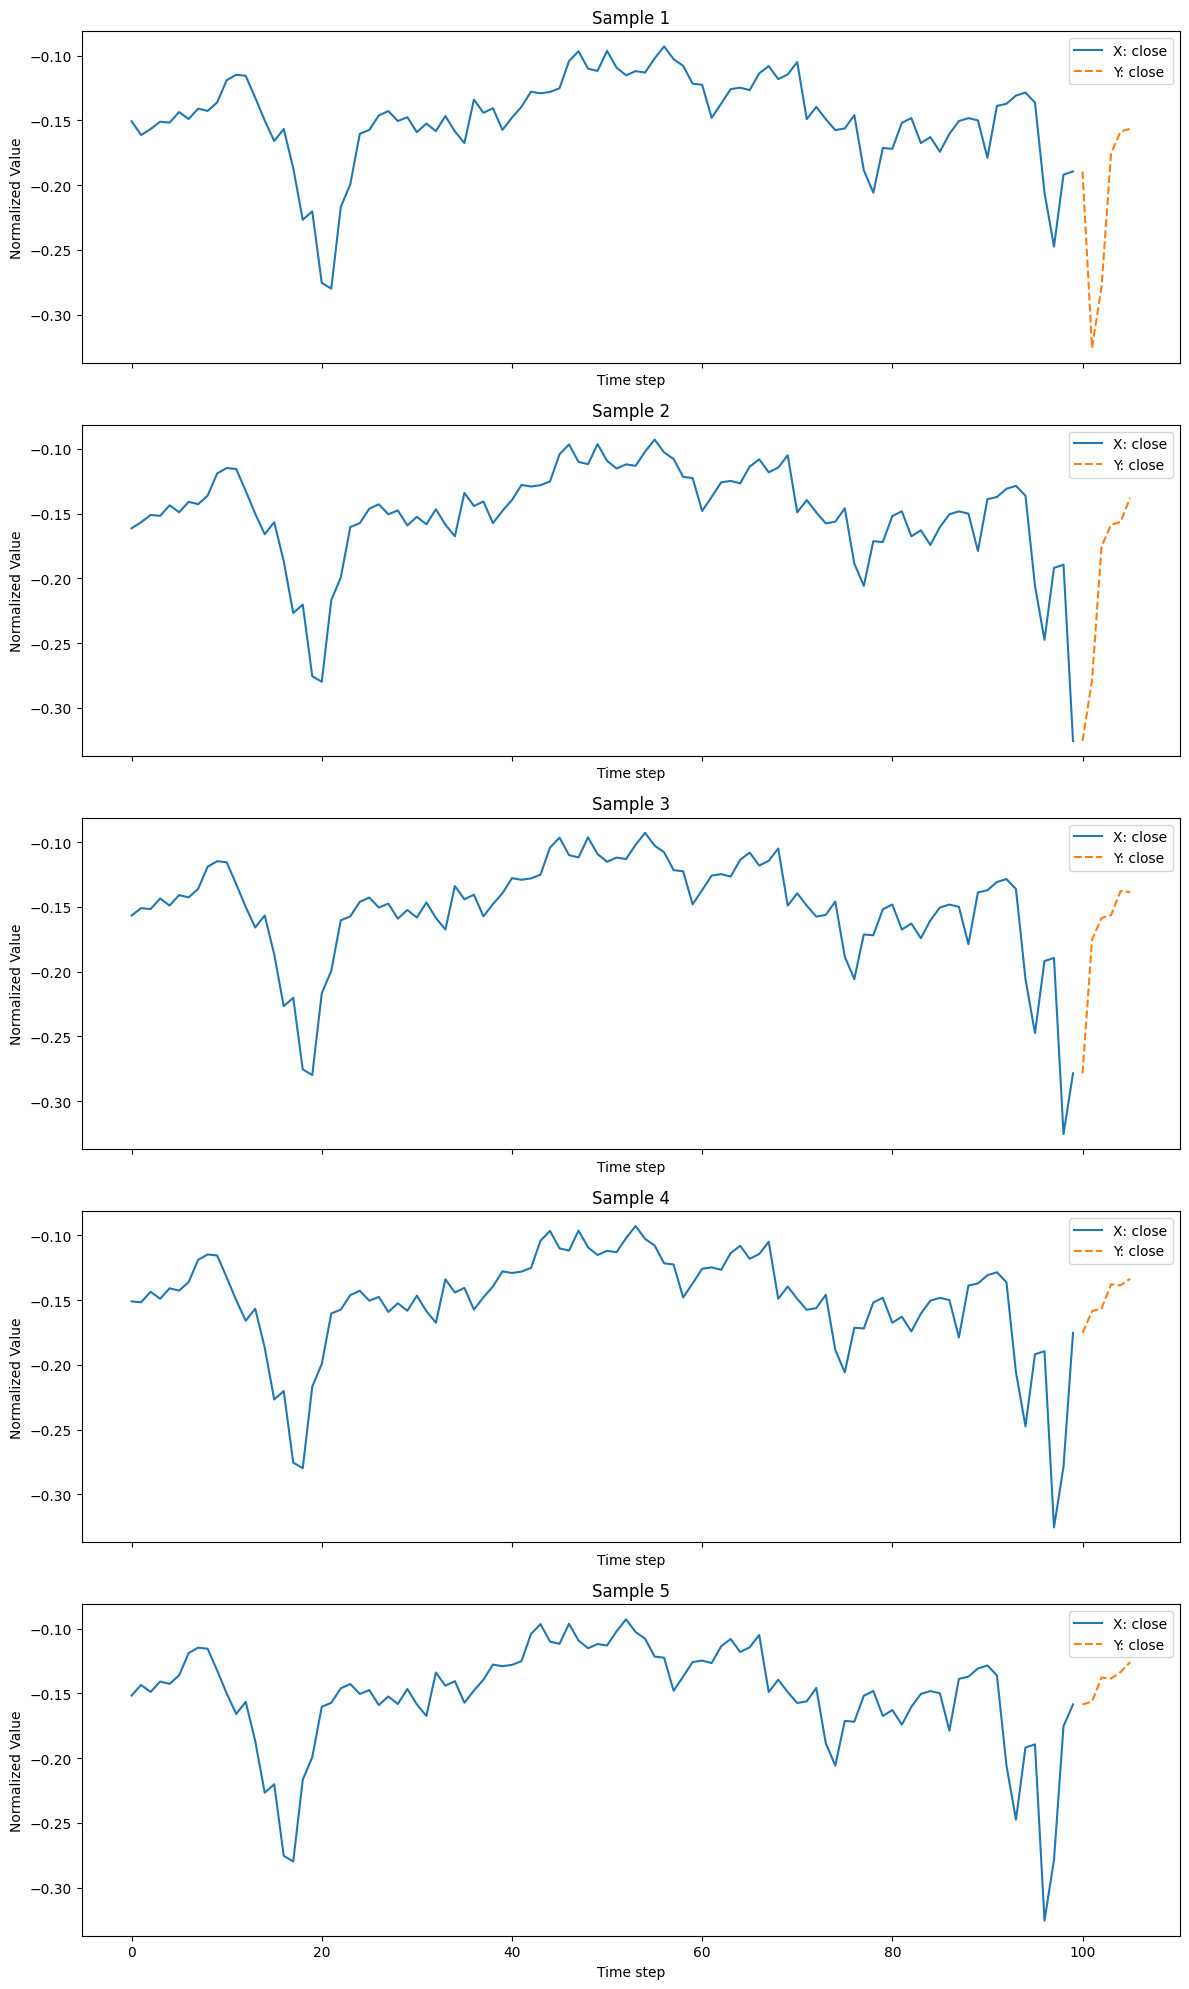

<bound method Module.parameters of TransformerTimeSeries(
  (input_projection): Linear(in_features=1, out_features=64, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_layer): Linear(in_features=64, out_features=6, bias=True)
)>
📉 Epoch 1: Train=0.0026 | Val=0.0016
📉 Epoch 2: Train=0.0015 | Val=0.0014
📉 Epoch 3: Tra

2025/09/16 17:25:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/16 17:25:43 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/09/16 17:25:46 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/09/16 17:25:46 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter whe

✅ TransformerTimeSeries | MAE=644.8382 RMSE=1261.9490
🏃 View run TransformerTimeSeries-BTCUSDT at: http://172.16.0.200/#/experiments/3/runs/552f9f93d48e4fa39c1ce8c1efdc2a50
🧪 View experiment at: http://172.16.0.200/#/experiments/3


In [20]:
# ---- MLflow-ready training loop (drop-in) ----
import os, io, json, tempfile, pathlib
import numpy as np
import pandas as pd
import mlflow
import mlflow.pytorch
import joblib, json, tempfile, os



# --- MLflow server + auth (set once) ---
os.environ.setdefault("MLFLOW_TRACKING_USERNAME", "user")
os.environ.setdefault("MLFLOW_TRACKING_PASSWORD", "SHIUZ1YJvMbu")
mlflow.set_tracking_uri("http://172.16.0.200")  # your LB on port 80

mlflow.set_experiment("crypto_forecasting")

output_dir = "reports"
os.makedirs(output_dir, exist_ok=True)

summary_path = os.path.join(output_dir, "summary_metrics.csv")
if not os.path.exists(summary_path):
    pd.DataFrame(columns=[
        "MAE", "RMSE", "Model", "Model Arch", "Coin", "Input Width", "Label Width",
        "Batch Size", "Learning Rate", "Num Epochs", "Windows Normalization Length",
        "Train Loss", "Validation Loss"
    ]).to_csv(summary_path, index=False)

loss_path = os.path.join(
    output_dir,
    f"loss_{model.__class__.__name__}_in{input_width}_out{label_width}_bs{batch_size}_lr{learning_rate}_win{windows_normalization_length}.png"
)


for model in models:
    model.to(device)

    # ---- one MLflow run per model ----
    model_name = model.__class__.__name__
    with mlflow.start_run(run_name=f"{model_name}-{coin}"):

        # (Optional) tag the run for easier filtering
        mlflow.set_tags({
            "coin": coin,
            "framework": "pytorch",
            "stage": "train",
        })

        # --- Train ---
        model, weights, train_l, val_l, scaler = train_model(
            coin=coin,
            model=model,
            input_width=input_width,
            label_width=label_width,
            lr=learning_rate,               # keeping your current var name
            max_epochs=num_epochs,
            patience=5
        )

        # --- Save & log loss plot ---
        save_loss_plot(train_l, val_l, loss_path)
        mlflow.log_artifact(loss_path, artifact_path="plots")

        # --- Dataset split & normalization (your code as-is) ---
        df = load_or_download(coin)

        def train_test(df_):
            n = len(df_)
            train_df = df_[0:int(n*0.7)]
            val_df   = df_[int(n*0.7):int(n*0.9)]
            test_df  = df_[int(n*0.9):]
            return train_df, val_df, test_df

        _, _, validate_raw = train_test(df[variables_used])

        test_df_zscore = normalize(validate_raw, label_width, window=windows_normalization_length)
        test_df_scaled = scaler.transform(test_df_zscore)
        test_df_scaled = pd.DataFrame(
            test_df_scaled,
            columns=test_df_zscore.columns,
            index=test_df_zscore.index
        )
        test_ds = WindowedDataset(test_df_scaled, input_width, label_width, 0, variables_used)
        test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

        # --- Predict ---
        model.eval()
        all_preds, all_targets = [], []
        import torch
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                all_preds.append(pred.cpu().numpy())
                all_targets.append(yb.cpu().numpy())

        all_preds   = np.concatenate(all_preds, axis=0)   # (num_windows, label_width, num_features)
        all_targets = np.concatenate(all_targets, axis=0)

        preds_minmax   = all_preds[:, :, close_idx]
        targets_minmax = all_targets[:, :, close_idx]

        preds_flat   = preds_minmax.reshape(-1, 1)
        targets_flat = targets_minmax.reshape(-1, 1)

        close_min = scaler.data_min_[close_idx]
        close_max = scaler.data_max_[close_idx]

        preds_zscore   = 0.5 * (preds_minmax + 1) * (close_max - close_min) + close_min
        targets_zscore = 0.5 * (targets_minmax + 1) * (close_max - close_min) + close_min

        denorm_preds   = np.zeros_like(preds_zscore)
        denorm_targets = np.zeros_like(targets_zscore)
        for i in range(preds_zscore.shape[0]):
            for j in range(label_width):
                idx = i + j + input_width  # alignment
                mean = validate_raw["close"].shift(label_width).rolling(window=windows_normalization_length).mean().iloc[idx]
                std  = validate_raw["close"].shift(label_width).rolling(window=windows_normalization_length).std().iloc[idx]
                denorm_preds[i, j]   = preds_zscore[i, j] * std + mean
                denorm_targets[i, j] = targets_zscore[i, j] * std + mean

        from sklearn.metrics import mean_absolute_error, mean_squared_error
        mae  = float(mean_absolute_error(denorm_targets.flatten(), denorm_preds.flatten()))
        rmse = float(np.sqrt(mean_squared_error(denorm_targets.flatten(), denorm_preds.flatten())))
        model_arch = str(model).replace('\n', '; ').strip()[:300]

        # ---- Log params & metrics to MLflow ----
        mlflow.log_params({
            "Model": model_name,
            "Coin": coin,
            "Input Width": input_width,
            "Label Width": label_width,
            "Batch Size": batch_size,
            "Learning Rate": learning_rate,
            "Num Epochs": num_epochs,
            "Windows Normalization Length": windows_normalization_length,
            "Device": str(device),
        })
        mlflow.log_metrics({
            "train_loss_last": float(train_l[-1]),
            "val_loss_last": float(val_l[-1]),
            "MAE": mae,
            "RMSE": rmse,
        })

        with tempfile.TemporaryDirectory() as tmp:
            joblib.dump(scaler, os.path.join(tmp, "scaler.joblib"))
            with open(os.path.join(tmp, "features.json"), "w") as f:
                json.dump({"features": variables_used}, f)
            mlflow.log_artifacts(tmp, artifact_path="preprocessing")

        # ---- Log model & weights ----
        # 1) log full PyTorch model (repro + easy load back)
        mlflow.pytorch.log_model(model, artifact_path="model")
        # 2) also store raw state_dict weights (handy for your codebase)
        with tempfile.TemporaryDirectory() as td:
            weights_path = os.path.join(td, f"{model_name}_{coin}_state_dict.pt")
            torch.save(weights, weights_path)
            mlflow.log_artifact(weights_path, artifact_path="weights")

        # ---- Append to your CSV AND log it as an artifact ----
        row_df = pd.DataFrame([{
            "MAE": mae,
            "RMSE": rmse,
            "Model": model_name,
            "Model Arch": model_arch,
            "Coin": coin,
            "Input Width": input_width,
            "Label Width": label_width,
            "Batch Size": batch_size,
            "Learning Rate": learning_rate,
            "Num Epochs": num_epochs,
            "Windows Normalization Length": windows_normalization_length,
            "Train Loss": float(train_l[-1]),
            "Validation Loss": float(val_l[-1]),
        }])
        row_df.to_csv(summary_path, mode='a', header=False, index=False)
        mlflow.log_artifact(summary_path, artifact_path="reports")

        print(f"✅ {model_name} | MAE={mae:.4f} RMSE={rmse:.4f}")


In [ ]:
import matplotlib.pyplot as plt
n_charts = 10
for i in range( 0, len(denorm_preds), len(denorm_preds)//n_charts):
    plt.figure(figsize=(6, 4))
    plt.plot(denorm_targets[i], label="Real Close", color="blue")
    plt.plot(denorm_preds[i], label="Predicted Close", color="orange")
    plt.title(f"Prediction Window {i+1}")
    plt.xlabel("Forecast Step")
    plt.ylabel("Close Price")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

